<a href="https://colab.research.google.com/github/amc-puc/ail-final-project/blob/main/Resturant_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import io
uploaded = files.upload()
print("Uploaded file keys:", list(uploaded.keys()))
filename = list(uploaded.keys())[0].rstrip('\\')
print("Using file:", filename)
df = pd.read_csv(io.BytesIO(uploaded[filename]), delimiter='\t')
df.head()


Saving Restaurant_Reviews.tsv to Restaurant_Reviews.tsv
Uploaded file keys: ['Restaurant_Reviews.tsv']
Using file: Restaurant_Reviews.tsv


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1leOFfG32xHWZlHN1f1QV8IAy3rAZvpH3Eh3h-vaAE6k/edit#gid=0


Sentiment Counts:
 Liked
0    500
1    500
Name: count, dtype: int64


<ipython-input-34-7c05346cdafd>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")


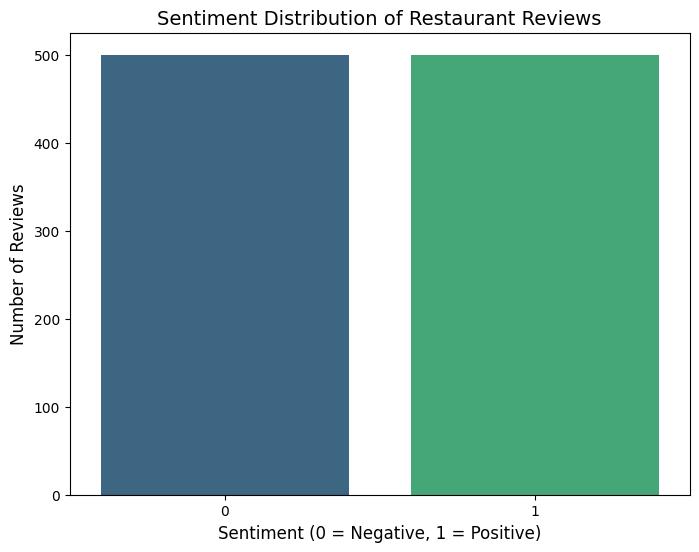

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sentiment_counts = df['Liked'].value_counts().sort_index()
print("Sentiment Counts:\n", sentiment_counts)
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Sentiment Distribution of Restaurant Reviews', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-35-26ba1a936070>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=pos_df, ax=axes[0], palette='Greens_r')
<ipython-input-35-26ba1a936070>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=neg_df, ax=axes[1], palette='Reds_r')


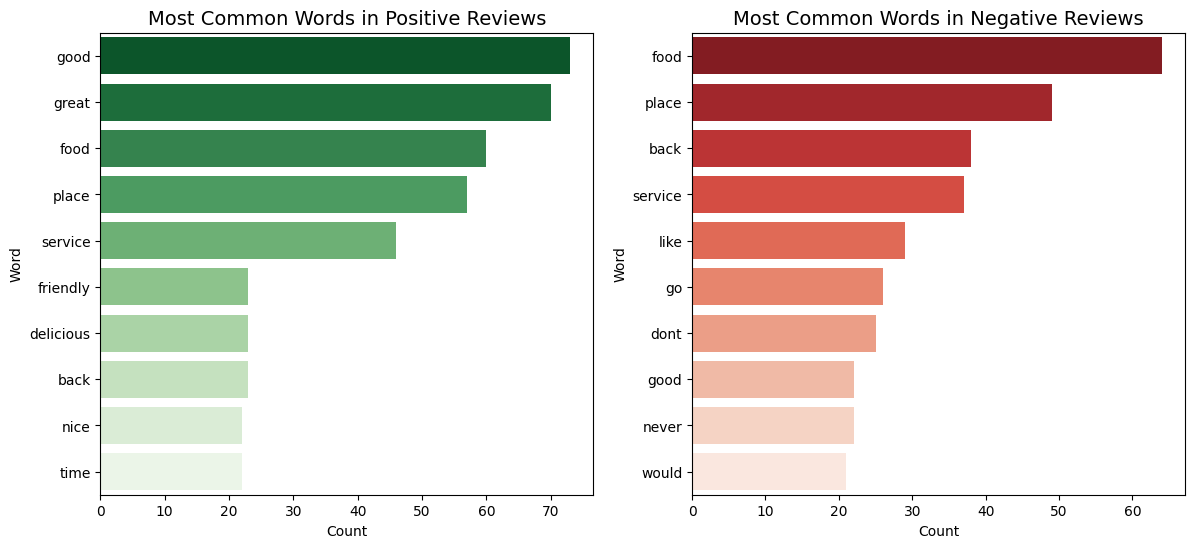

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    words = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return [word for word in words if word not in stop_words]
positive_reviews = " ".join(df[df['Liked'] == 1]['Review'])
negative_reviews = " ".join(df[df['Liked'] == 0]['Review'])
positive_words = Counter(preprocess_text(positive_reviews)).most_common(10)
negative_words = Counter(preprocess_text(negative_reviews)).most_common(10)
pos_df = pd.DataFrame(positive_words, columns=['Word', 'Count'])
neg_df = pd.DataFrame(negative_words, columns=['Word', 'Count'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='Count', y='Word', data=pos_df, ax=axes[0], palette='Greens_r')
sns.barplot(x='Count', y='Word', data=neg_df, ax=axes[1], palette='Reds_r')
axes[0].set_title("Most Common Words in Positive Reviews", fontsize=14)
axes[1].set_title("Most Common Words in Negative Reviews", fontsize=14)
plt.show()


In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
corpus = []
ps = PorterStemmer();

for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['Review'][i])
    review = review.lower()
    review_words = review.split()
    review_words = [ps.stem(word) for word in review_words if word not in stopwords.words('english')]
    cleaned_review = ' '.join(review_words)
    corpus.append(cleaned_review)

print(corpus[0])


wow love place
